# Synthetic Point Circle and Persistent Homology tests

Notebook to verify that the project enviroment is functioning correctly by computing the persisten homology of synthetic point clouds.

Simple circle expected results:
- Many connected components in \(H_0\) that gradually merge;
- One prominent \(H_1\) loop.

In [4]:
import sys 
from pathlib import Path

print("Python executable:")
print(sys.executable)

print("\nCurrent working directory:")
print(Path.cwd())

Python executable:
C:\Users\Matteo Meyer\Projects\tda-time-series-classification\.venv\Scripts\python.exe

Current working directory:
C:\Users\Matteo Meyer\Projects\tda-time-series-classification\notebooks


In [6]:
import numpy as np 
import matplotlib.pyplot as plt

from ripser import ripser
from persim import plot_diagrams

print("Scientific and TDA imports succesful")

rng = np.random.default_rng(2408)


Scientific and TDA imports succesful


## Sampled circles

Points are sampled evenly from the 2d unit circle.

In [7]:
n_points = 100
theta  = np.linspace(
    0.0,
    2.9 * np.pi,
    n_points,
    endpoint = False,
)
circle = np.column_stack(
    (
        np.cos(theta),
        np.sin(theta),
    )
)

print("Point-cloud shape: ", circle.shape)

Point-cloud shape:  (100, 2)


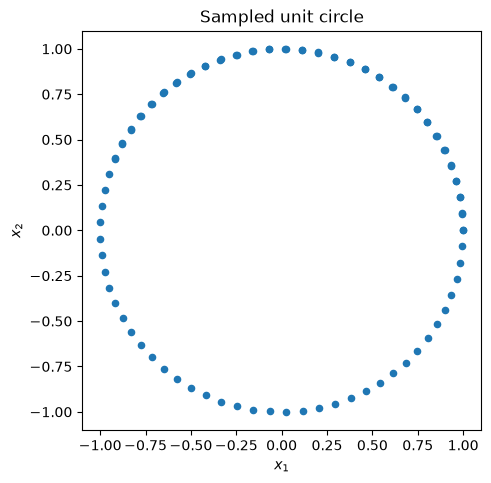

In [8]:
fig, ax = plt.subplots(figsize = (5, 5))

ax.scatter(
    circle[:, 0],
    circle[:, 1],
    s = 20,
)

ax.set_title("Sampled unit circle")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_aspect("equal")

fig.tight_layout()
plt.show()

## Vietoris-Rips persisten homology

We compute the persistent homology in dimensions 0 and 1 (H0 = connected components; H1 = loops).

In [9]:
results = ripser(
    circle, 
    maxdim = 1,
)

diagrams = results["dgms"]

print("numbers of diagrams:", len(diagrams))
print("H0 diagram shape:", diagrams[0].shape)
print("H1 diagram shape:", diagrams[1].shape)

numbers of diagrams: 2
H0 diagram shape: (100, 2)
H1 diagram shape: (1, 2)


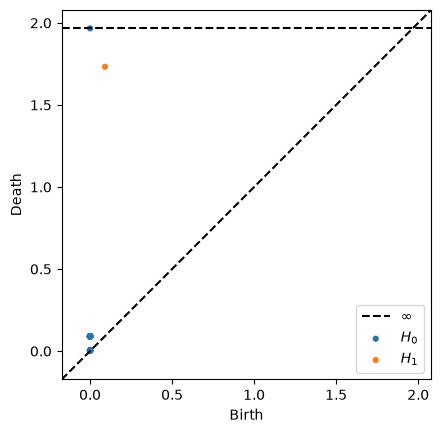

In [10]:
plot_diagrams(
    diagrams,
    show=True,
)

In [11]:
print("H0 persistence intervals:")
print(diagrams[0])

print("\nH1 persistence intervals:")
print(diagrams[1])

H0 persistence intervals:
[[0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.00314159]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]
 [0.         0.08793624]

In [12]:
h1_birth = diagrams[1][0, 0]
h1_death = diagrams[1][0, 1]
h1_persistence = h1_death - h1_birth

print("H1 birth:", h1_birth)
print("H1 death:", h1_death)
print("H1 persistence:", h1_persistence)

H1 birth: 0.09107468277215958
H1 death: 1.732574224472046
H1 persistence: 1.6414995416998863


In [13]:
assert len(diagrams) == 2
assert diagrams[1].shape[0] >= 1

print("Persistence check passed.")

Persistence check passed.


# Persistent Homology Tests on more Synthetic Point Clouds
The persisten homology of different kinds of point clouds is computed, along with the corresponding persistence diagrams, in particular:
1. Clean circle vs Noisy circle;
2. Separate clusters;
3. Figure eight;
4. Uniformly sampled random point cloud.

## 1. Noisy Circle

In [14]:
noise = rng.normal(loc=0, scale=0.1, size=(100, 2))
noisy_circle = circle + noise     #The circle is taken from the previous compuations done

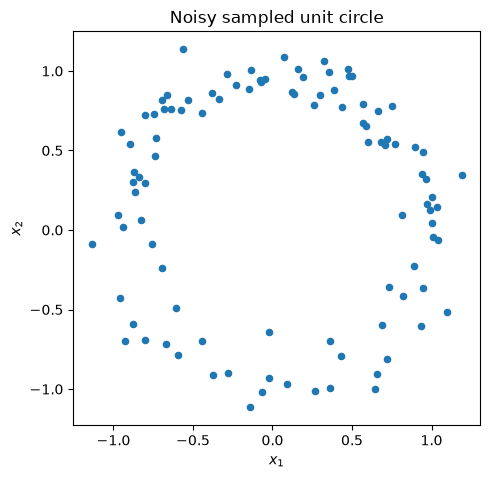

In [15]:
fig_2 , ax_2 = plt.subplots(figsize = (5, 5))
ax_2.scatter(noisy_circle[:, 0],
            noisy_circle[:, 1],
            s=20,
)
ax_2.set_title("Noisy sampled unit circle")
ax_2.set_xlabel("$x_1$")
ax_2.set_ylabel("$x_2$")
ax_2.set_aspect("equal")
fig_2.tight_layout()
plt.show()

## Persistent Homology of a Noisy Circle

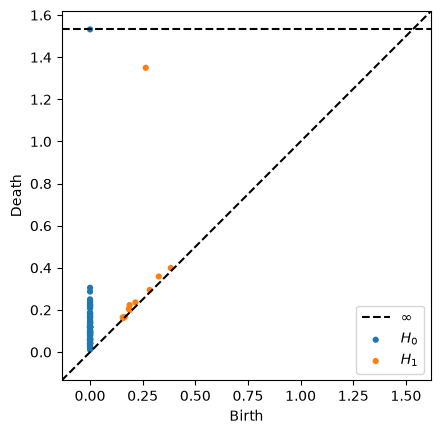

In [16]:
results_2 = ripser(noisy_circle,
                   maxdim=1,
)
diagrams_2 = results_2["dgms"]
plot_diagrams(diagrams_2,
             show=True,
)

In [17]:
noisy_H0 = diagrams_2[0]
noisy_H1 = diagrams_2[1]
print("H0 intervals: \n", noisy_H0, "\n H1 intervals: \n", noisy_H1)

H0 intervals: 
 [[0.         0.01189498]
 [0.         0.01796873]
 [0.         0.02132755]
 [0.         0.02539295]
 [0.         0.02656605]
 [0.         0.03188917]
 [0.         0.03745643]
 [0.         0.03997462]
 [0.         0.04002222]
 [0.         0.04042988]
 [0.         0.0426002 ]
 [0.         0.0433008 ]
 [0.         0.04397945]
 [0.         0.04495612]
 [0.         0.04769959]
 [0.         0.05392002]
 [0.         0.05475771]
 [0.         0.05634189]
 [0.         0.05760337]
 [0.         0.05890306]
 [0.         0.05897169]
 [0.         0.06018306]
 [0.         0.06051348]
 [0.         0.0614344 ]
 [0.         0.06233999]
 [0.         0.06378712]
 [0.         0.06854209]
 [0.         0.0717553 ]
 [0.         0.07856432]
 [0.         0.07876749]
 [0.         0.0797138 ]
 [0.         0.08032566]
 [0.         0.08520309]
 [0.         0.08576616]
 [0.         0.08669773]
 [0.         0.0868364 ]
 [0.         0.08813713]
 [0.         0.09103322]
 [0.         0.09189367]
 [0.     

## 2. Two Separate Clusters 

In [21]:
cluster1 = rng.normal(loc=(-1, 1), scale=0.2, size=(100, 2))
cluster2 = rng.normal(loc=(1, -1), scale=0.2, size=(100, 2))
joint_clusters = np.vstack((cluster1, cluster2))

(200, 2)

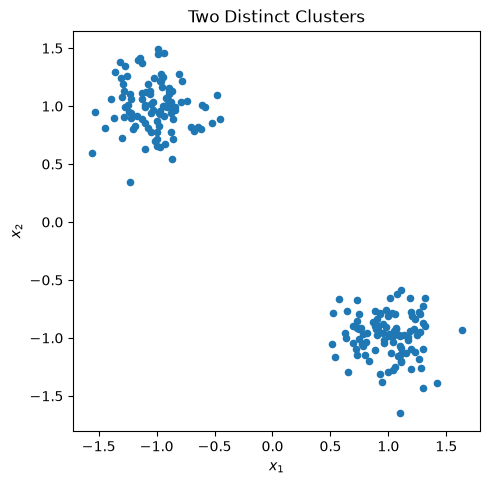

In [25]:
fig_3, ax_3 = plt.subplots(figsize = (5, 5))
ax_3.scatter(joint_clusters[:, 0],
            joint_clusters[:, 1],
            s = 20,
)
ax_3.set_title("Two Distinct Clusters")
ax_3.set_xlabel("$x_1$")
ax_3.set_ylabel("$x_2$")
ax_3.set_aspect("equal")
fig_3.tight_layout()
plt.show()

## Persistent Homology of 2 separate Clusters

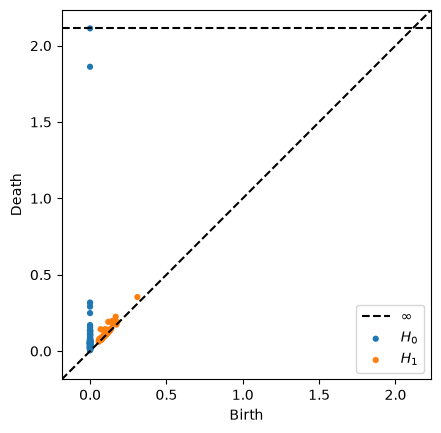

In [28]:
results_3 = ripser(joint_clusters, maxdim = 1,
                  )
diagrams_3 = results_3["dgms"]
plot_diagrams(diagrams_3, show = True)

In [32]:
clusters_H0 = diagrams_3[0]
clusters_H1 = diagrams_3[1]
print("H0 intervals:", clusters_H0, "H1 intervals: ", clusters_H1, sep = "\n")

H0 intervals:
[[0.         0.0056201 ]
 [0.         0.00672792]
 [0.         0.00792393]
 [0.         0.00933689]
 [0.         0.00980855]
 [0.         0.01060479]
 [0.         0.01198634]
 [0.         0.01320436]
 [0.         0.01376399]
 [0.         0.01414497]
 [0.         0.01441899]
 [0.         0.01524039]
 [0.         0.01643427]
 [0.         0.01878963]
 [0.         0.0189907 ]
 [0.         0.01909654]
 [0.         0.0196269 ]
 [0.         0.01972914]
 [0.         0.02073688]
 [0.         0.02082614]
 [0.         0.0210439 ]
 [0.         0.02117226]
 [0.         0.02157866]
 [0.         0.02214921]
 [0.         0.02284246]
 [0.         0.02304184]
 [0.         0.02371932]
 [0.         0.02398501]
 [0.         0.0241027 ]
 [0.         0.02437858]
 [0.         0.02456189]
 [0.         0.02468698]
 [0.         0.02547984]
 [0.         0.02568474]
 [0.         0.02589096]
 [0.         0.02620499]
 [0.         0.0270454 ]
 [0.         0.02724979]
 [0.         0.02737542]
 [0.       

## 3. Figure Eight Point Cloud

In [64]:
theta_8 = np.linspace(0, 2*np.pi, 100, endpoint = False)
left_circle = np.column_stack(
    (np.cos(theta_8)-1,
    np.sin(theta_8),
    )    
)
right_circle = np.column_stack(
    (np.cos(theta_8)+1,
    np.sin(theta_8),
    )
)
right_circle_no_origin = np.delete(right_circle, 50, axis = 0)

figure_8 = np.vstack((left_circle, right_circle_no_origin))

figure_8_noise = rng.normal(loc = 0, scale = 0.1, size = figure_8.shape)

noisy_figure_8 = figure_8 + figure_8_noise

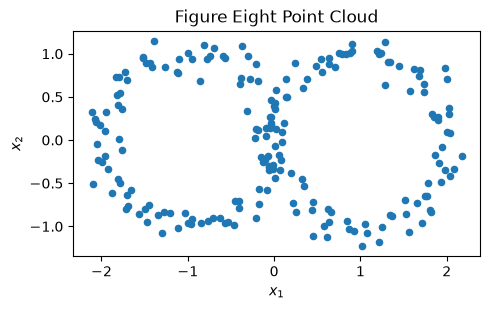

In [65]:
fig_4, ax_4 = plt.subplots(figsize = (5, 5))
ax_4.scatter(noisy_figure_8[:, 0],
            noisy_figure_8[:, 1],
            s = 20,
)
ax_4.set_title("Figure Eight Point Cloud")
ax_4.set_xlabel("$x_1$")
ax_4.set_ylabel("$x_2$")
ax_4.set_aspect("equal")
fig_4.tight_layout()
plt.show()

## Persistent Homology of a Figure Eight Point Cloud

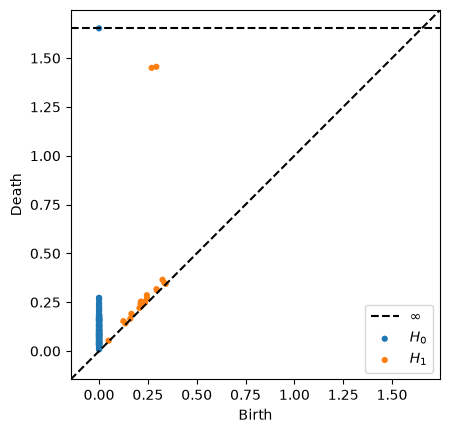

In [68]:
results_4 = ripser(noisy_figure_8, maxdim = 1,)
diagrams_4 = results_4["dgms"]
plot_diagrams(diagrams_4, show = True)

In [69]:
figure_8_H0 = diagrams_4[0]
figure_8_H1 = diagrams_4[1]
print("H0 intervals:", figure_8_H0, "H1 intervals: ", figure_8_H1, sep = "\n")

H0 intervals:
[[0.         0.00872886]
 [0.         0.00931443]
 [0.         0.01250331]
 [0.         0.01780092]
 [0.         0.01917101]
 [0.         0.02339532]
 [0.         0.02487941]
 [0.         0.02710456]
 [0.         0.02736312]
 [0.         0.02967913]
 [0.         0.03202739]
 [0.         0.03224651]
 [0.         0.03377249]
 [0.         0.03465956]
 [0.         0.03483793]
 [0.         0.03504864]
 [0.         0.03507587]
 [0.         0.03521235]
 [0.         0.0355492 ]
 [0.         0.0363011 ]
 [0.         0.03723093]
 [0.         0.03769659]
 [0.         0.03787253]
 [0.         0.03993269]
 [0.         0.04051365]
 [0.         0.04169074]
 [0.         0.04227538]
 [0.         0.04267098]
 [0.         0.04339607]
 [0.         0.04358556]
 [0.         0.04382744]
 [0.         0.04489858]
 [0.         0.04490976]
 [0.         0.04613544]
 [0.         0.04634926]
 [0.         0.0466007 ]
 [0.         0.04835958]
 [0.         0.04907903]
 [0.         0.04957668]
 [0.       

In [77]:
figure_8_H1_persistence = figure_8_H1[:,1] - figure_8_H1[:, 0]

np.sort(figure_8_H1_persistence)[-10:]

a = np.argsort(figure_8_H1_persistence)[-2:]
figure_8_H1[a]

array([[0.29327402, 1.45553863],
       [0.26919854, 1.4498744 ]])

## 4. Random Point Cloud
As a final base case for comparison, the persisten homology of a random point cloud is computed.

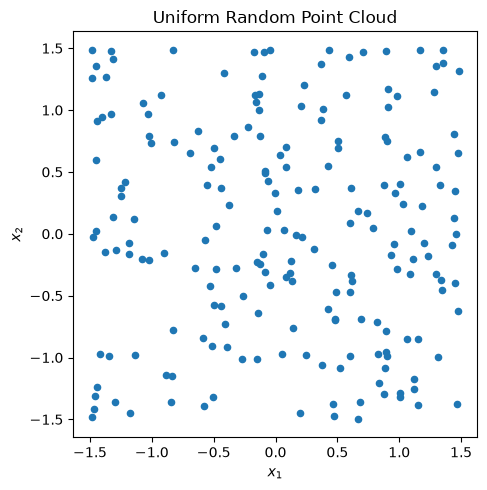

In [80]:
random_cloud = rng.uniform(low = -1.5, high = 1.5, size = (200, 2))

fig_5, ax_5 = plt.subplots(figsize = (5, 5))
ax_5.scatter(random_cloud[:, 0],
            random_cloud[:, 1],
            s = 20,
)
ax_5.set_title("Uniform Random Point Cloud")
ax_5.set_xlabel("$x_1$")
ax_5.set_ylabel("$x_2$")
ax_5.set_aspect("equal")
fig_5.tight_layout()
plt.show()

## Persistent Homology of a Random Point Cloud

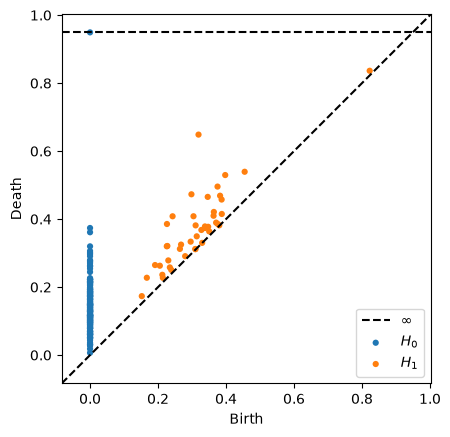

In [82]:
results_5 = ripser(random_cloud, maxdim = 1,)
diagrams_5 = results_5["dgms"]
plot_diagrams(diagrams_5, show = True)

In [84]:
random_cloud_H0 = diagrams_5[0]
random_cloud_H1 = diagrams_5[1]
print("H0 intervals:", random_cloud_H0, "H1 intervals: ", random_cloud_H1, sep = "\n")

H0 intervals:
[[0.         0.00671938]
 [0.         0.01819009]
 [0.         0.02786611]
 [0.         0.03016197]
 [0.         0.03145276]
 [0.         0.03238524]
 [0.         0.03622204]
 [0.         0.0433137 ]
 [0.         0.04805247]
 [0.         0.04893498]
 [0.         0.04983464]
 [0.         0.05159459]
 [0.         0.05213501]
 [0.         0.05251205]
 [0.         0.05268269]
 [0.         0.05756459]
 [0.         0.05996503]
 [0.         0.06002506]
 [0.         0.06011856]
 [0.         0.06072645]
 [0.         0.06180314]
 [0.         0.06236982]
 [0.         0.06316862]
 [0.         0.06397167]
 [0.         0.06741324]
 [0.         0.06810161]
 [0.         0.06818224]
 [0.         0.06865105]
 [0.         0.0697458 ]
 [0.         0.07126557]
 [0.         0.07189614]
 [0.         0.07752798]
 [0.         0.07805703]
 [0.         0.07893109]
 [0.         0.07914023]
 [0.         0.07974094]
 [0.         0.08083624]
 [0.         0.08243445]
 [0.         0.0851589 ]
 [0.       